In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")

In [110]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "postgresql://robot-startml-ro:pheiph0hahj1Vaif@"
    "postgres.lab.karpov.courses:6432/startml"
)


In [117]:
feed = pd.read_sql(
    """
    SELECT user_id, post_id, timestamp, target
    FROM public.feed_data
    WHERE action = 'view'
    LIMIT 1000000 
    """,
    con=engine
)

In [118]:
users = pd.read_sql(
    """
    SELECT user_id, age, gender, country, os, source, exp_group
    FROM public.user_data
    """,
    con=engine
)

In [119]:
posts = pd.read_sql(
    """
    SELECT post_id, topic, text
    FROM public.post_text_df
    """,
    con=engine
)

In [120]:
feed.to_csv('feed.csv', index=False)
users.to_csv('users.csv', index=False)
posts.to_csv('posts.csv', index=False)

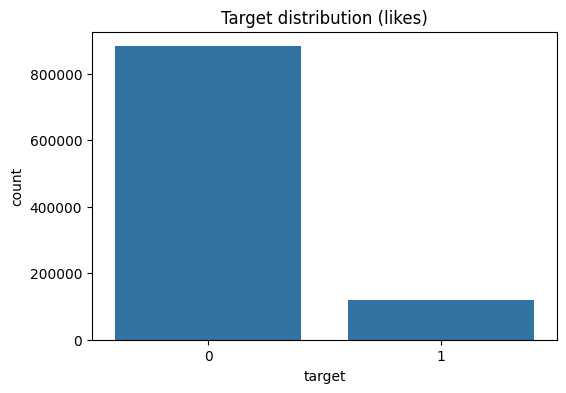

In [121]:
plt.figure(figsize=(6,4))
sns.countplot(x=feed['target'])
plt.title("Target distribution (likes)")
plt.show()

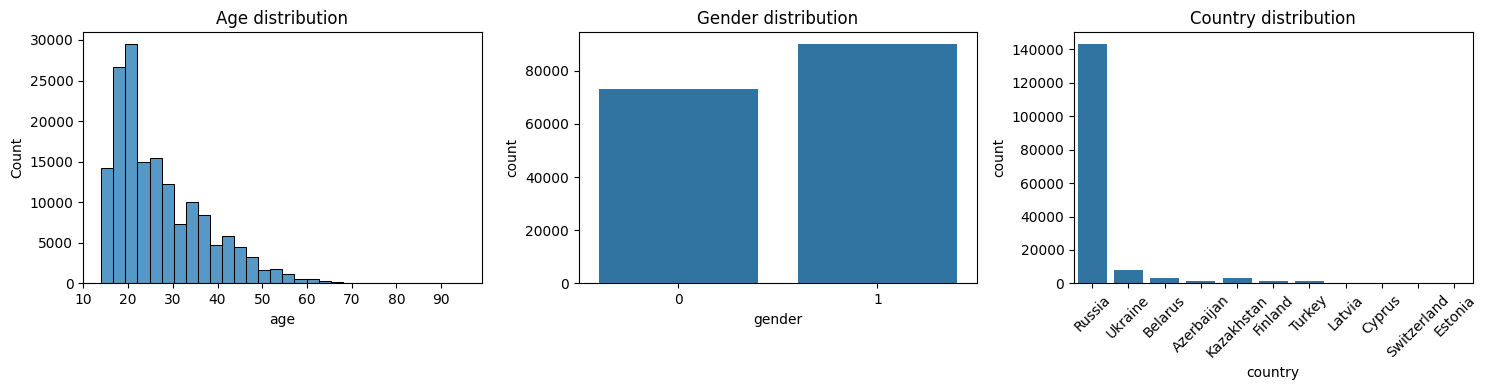

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(users['age'], bins=30, ax=axes[0])
axes[0].set_title("Age distribution")

sns.countplot(x=users['gender'], ax=axes[1])
axes[1].set_title("Gender distribution")

sns.countplot(x=users['country'], ax=axes[2])
axes[2].set_title("Country distribution")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [123]:
posts['text_len'] = posts['text'].str.len()
posts['words_count'] = posts['text'].str.split().apply(len)
posts['unique_words_count'] = posts['text'].str.split().apply(lambda x: len(set(x)))

posts = posts.drop(columns=['text'])

In [124]:
split_time = feed['timestamp'].quantile(0.8)

feed_train = feed[feed['timestamp'] < split_time].copy()
feed_test = feed[feed['timestamp'] >= split_time].copy()

In [125]:
train = feed_train.merge(users, on="user_id", how="left").merge(posts, on="post_id", how="left")
test = feed_test.merge(users, on="user_id", how="left").merge(posts, on="post_id", how="left")

In [ ]:
user_stats = feed_train.groupby("user_id").agg(
    user_views=("post_id", "count"), 
    user_likes=("target", "sum"), 
    user_like_rate=("target", "mean") 
).reset_index()

train = train.merge(user_stats, on="user_id", how="left")
test = test.merge(user_stats, on="user_id", how="left")


In [ ]:
post_stats = feed_train.groupby("post_id").agg( 
    post_views=("user_id", "count"),
    post_likes=("target", "sum"),
    post_like_rate=("target", "mean")
).reset_index()

train = train.merge(post_stats, on="post_id", how="left")
test = test.merge(post_stats, on="post_id", how="left")

In [128]:
tmp = feed_train.merge(
    posts[["post_id", "topic"]],
    on="post_id",
    how="left"
)

user_topic = tmp.groupby(["user_id", "topic"]).agg(
    user_topic_views=("post_id", "count"),
    user_topic_likes=("target", "sum"),
    user_topic_like_rate=("target", "mean")
).reset_index()

train = train.merge(user_topic, on=["user_id", "topic"], how="left")
test = test.merge(user_topic, on=["user_id", "topic"], how="left")


In [129]:
DROP_COLS = ['user_id', 'post_id', 'timestamp', 'target']

X_train = train.drop(columns=DROP_COLS)
X_test = test.drop(columns=DROP_COLS)

y_train = train['target']
y_test = test['target']

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_train[cat_cols] = X_train[cat_cols].fillna('unknown')
X_test[cat_cols] = X_test[cat_cols].fillna('unknown')

X_train[num_cols] = X_train[num_cols].fillna(0)
X_test[num_cols] = X_test[num_cols].fillna(0)

In [130]:
train

,user_id,post_id,timestamp,target,age,gender,country,os,source,exp_group,...,unique_words_count,user_views,user_likes,user_like_rate,post_views,post_likes,post_like_rate,user_topic_views,user_topic_likes,user_topic_like_rate
0,63050,6005,2021-11-21 16:04:06,0,19,1,Russia,Android,ads,3,...,124,195,25,0.128205,81,15,0.185185,83,9,0.108434
1,63050,6493,2021-11-21 16:04:33,0,19,1,Russia,Android,ads,3,...,279,195,25,0.128205,83,12,0.144578,83,9,0.108434
2,63050,4996,2021-11-21 16:05:47,0,19,1,Russia,Android,ads,3,...,164,195,25,0.128205,96,10,0.104167,83,9,0.108434
3,63050,1433,2021-11-26 14:15:42,0,19,1,Russia,Android,ads,3,...,125,195,25,0.128205,260,32,0.123077,24,4,0.166667
4,63050,3791,2021-11-26 14:16:16,0,19,1,Russia,Android,ads,3,...,19,195,25,0.128205,248,30,0.120968,45,6,0.133333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799995,154034,527,2021-11-19 21:18:53,0,23,1,Russia,Android,organic,3,...,126,267,9,0.033708,98,12,0.122449,17,2,0.117647
799996,154034,691,2021-11-19 21:19:58,0,23,1,Russia,Android,organic,3,...,195,267,9,0.033708,109,15,0.137615,23,1,0.043478
799997,154034,4814,2021-11-19 21:22:55,0,23,1,Russia,Android,organic,3,...,176,267,9,0.033708,80,10,0.125000,109,3,0.027523
799998,154034,7044,2021-11-19 21:25:41,0,23,1,Russia,Android,organic,3,...,73,267,9,0.033708,91,8,0.087912,109,3,0.027523


In [131]:
train.drop(columns=['user_id', 'post_id'], inplace=True)

In [132]:
test

,user_id,post_id,timestamp,target,age,gender,country,os,source,exp_group,...,unique_words_count,user_views,user_likes,user_like_rate,post_views,post_likes,post_like_rate,user_topic_views,user_topic_likes,user_topic_like_rate
0,153809,5715,2021-12-16 15:01:20,0,22,1,Russia,iOS,organic,2,...,45,16.0,3.0,0.187500,190,27,0.142105,8.0,1.0,0.125000
1,153809,6989,2021-12-16 15:02:37,0,22,1,Russia,iOS,organic,2,...,227,16.0,3.0,0.187500,162,31,0.191358,8.0,1.0,0.125000
2,153809,3654,2021-12-16 15:04:04,0,22,1,Russia,iOS,organic,2,...,20,16.0,3.0,0.187500,207,35,0.169082,5.0,0.0,0.000000
3,153809,1230,2021-12-16 15:04:55,1,22,1,Russia,iOS,organic,2,...,310,16.0,3.0,0.187500,179,15,0.083799,NaN,NaN,NaN
4,153809,4433,2021-12-16 15:07:05,0,22,1,Russia,iOS,organic,2,...,96,16.0,3.0,0.187500,212,34,0.160377,8.0,1.0,0.125000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,50603,4843,2021-12-12 18:56:04,0,35,1,Russia,Android,ads,1,...,101,446.0,78.0,0.174888,228,37,0.162281,123.0,35.0,0.284553
199996,50603,4373,2021-12-12 18:58:27,1,35,1,Russia,Android,ads,1,...,145,446.0,78.0,0.174888,80,8,0.100000,123.0,35.0,0.284553
199997,50603,591,2021-12-12 18:59:01,1,35,1,Russia,Android,ads,1,...,231,446.0,78.0,0.174888,103,8,0.077670,20.0,6.0,0.300000
199998,50603,6496,2021-12-12 19:00:49,0,35,1,Russia,Android,ads,1,...,92,446.0,78.0,0.174888,62,9,0.145161,123.0,35.0,0.284553


In [133]:
train.to_csv('train.csv', index=False)

In [134]:
test.to_csv('test.csv', index=False)

In [135]:
df = pd.concat([train, test], axis=0, ignore_index=True)

In [136]:
df.to_csv('df.csv', index=False)

In [137]:
"""
df.to_sql(
   "irina_azarova_features_lesson_22",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=50_000,
    method="multi"
)
"""

'\ndf.to_sql(\n   "irina_azarova_features_lesson_22",\n    con=engine,\n    if_exists="replace",\n    index=False,\n    chunksize=50_000,\n    method="multi"\n)\n'

In [138]:
from catboost import CatBoostClassifier


In [139]:
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=7,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=50
)

In [140]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.6213059	best: 0.6213059 (0)	total: 138ms	remaining: 41.4s
50:	test: 0.6616622	best: 0.6618318 (47)	total: 5.39s	remaining: 26.3s
100:	test: 0.6639315	best: 0.6639315 (100)	total: 10.9s	remaining: 21.5s
150:	test: 0.6642400	best: 0.6642434 (149)	total: 15.5s	remaining: 15.3s
200:	test: 0.6648489	best: 0.6648489 (200)	total: 20.3s	remaining: 10s
250:	test: 0.6649826	best: 0.6649893 (246)	total: 25.1s	remaining: 4.9s
299:	test: 0.6648375	best: 0.6649893 (246)	total: 29.8s	remaining: 0us

bestTest = 0.6649893084
bestIteration = 246

Shrink model to first 247 iterations.


In [141]:
from sklearn.metrics import roc_auc_score

proba = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, proba)

np.float64(0.6649893083734333)

In [142]:
test["score"] = model.predict_proba(X_test)[:, 1]


In [ ]:
def hitrate_at_k(df, k=5):
    hits = []

    for user_id, group in df.groupby("user_id"): 
        top_k = group.sort_values("score", ascending=False).head(k)
        hit = int(top_k["target"].max() == 1)
        hits.append(hit)

    return sum(hits) / len(hits)

In [144]:
hr5 = hitrate_at_k(test, k=5)
print(f"HitRate@5 = {hr5:.4f}")

HitRate@5 = 0.6592


In [ ]:
model.save_model("model_control.cbm", format="cbm")


In [146]:
import os
from catboost import CatBoostClassifier


def get_model_path(path: str) -> str:
    if os.environ.get("IS_LMS") == "1":
        MODEL_PATH = "/workdir/user_input/model"
    else:
        MODEL_PATH = path
    return MODEL_PATH


def load_models():
    model_path = get_model_path("catboost_model.cbm")

    model = CatBoostClassifier()
    model.load_model(model_path)

    return model

In [147]:
loaded_model = load_models()
loaded_model.predict_proba(X_test[:10])


array([[7.79622237e-01, 2.20377763e-01],
       [7.66849113e-01, 2.33150887e-01],
       [9.99766162e-01, 2.33837669e-04],
       [9.99970069e-01, 2.99313527e-05],
       [7.60682081e-01, 2.39317919e-01],
       [9.99957981e-01, 4.20188813e-05],
       [8.02472404e-01, 1.97527596e-01],
       [8.03149701e-01, 1.96850299e-01],
       [9.99972216e-01, 2.77841755e-05],
       [9.99972630e-01, 2.73700167e-05]])

In [148]:
import features

df = features.load_features()


In [149]:
df.head()

,user_id,age,gender,country,os,source,exp_group,user_views,user_likes,user_like_rate
0,200,34,1,Russia,Android,ads,3,0.0,0.0,0.0
1,201,37,0,Russia,Android,ads,0,0.0,0.0,0.0
2,202,17,1,Russia,Android,ads,4,0.0,0.0,0.0
3,203,18,0,Russia,iOS,ads,1,0.0,0.0,0.0
4,204,36,0,Russia,Android,ads,3,0.0,0.0,0.0


In [150]:
user_stats = feed.groupby("user_id").agg(
    user_views=("post_id", "count"),
    user_likes=("target", "sum"),
    user_like_rate=("target", "mean"),
).reset_index()

In [151]:
user_features = users.merge(
    user_stats,
    on="user_id",
    how="left"   
)

In [152]:
cat_cols = user_features.select_dtypes(include=["object"]).columns
num_cols = user_features.select_dtypes(include=["int64", "float64"]).columns

user_features[cat_cols] = user_features[cat_cols].fillna("unknown")
user_features[num_cols] = user_features[num_cols].fillna(0)

In [153]:
print(len(user_features))
print(users["user_id"].nunique())
print(user_features["user_id"].nunique())

163205
163205
163205


In [154]:
print(user_features["user_id"].nunique())
print(users["user_id"].nunique())
print(10 in user_features["user_id"].values)

163205
163205
False


In [155]:
user_features.to_sql(
    "irina_azarova_features_lesson_22_users",
    con=engine,
    if_exists="replace",   
    index=False,
    chunksize=50000,
    method="multi"
)

163205

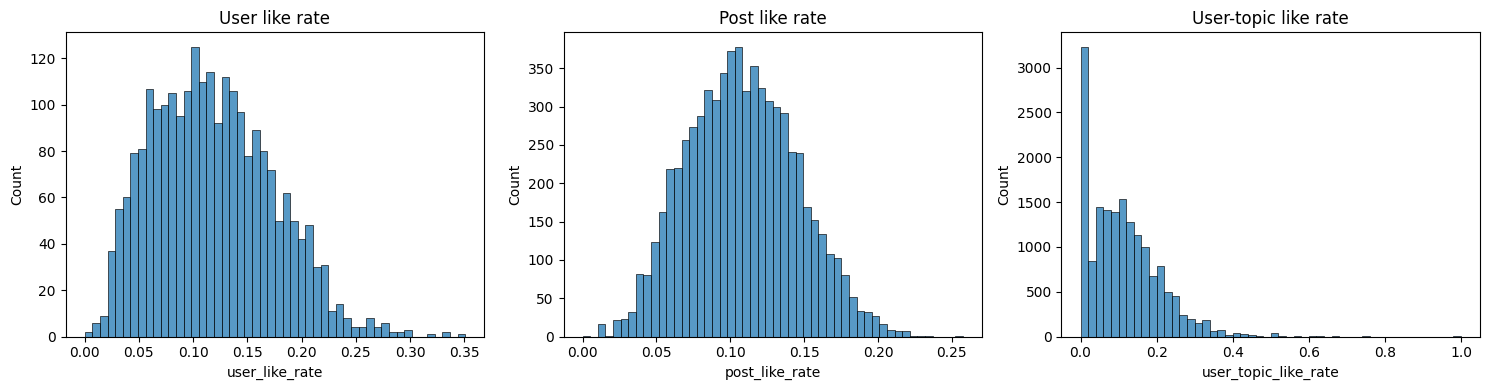

In [156]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(user_stats['user_like_rate'], bins=50, ax=axes[0])
axes[0].set_title("User like rate")

sns.histplot(post_stats['post_like_rate'], bins=50, ax=axes[1])
axes[1].set_title("Post like rate")

sns.histplot(user_topic['user_topic_like_rate'], bins=50, ax=axes[2])
axes[2].set_title("User-topic like rate")

plt.tight_layout()
plt.show()

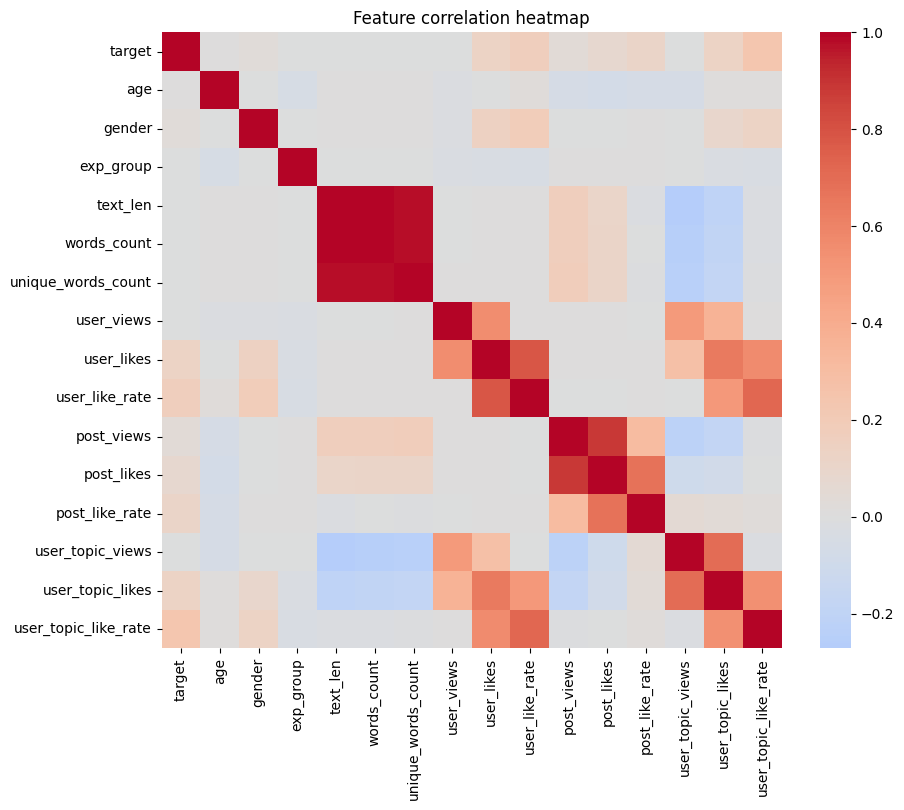

In [157]:
num_features = train.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(num_features.corr(), cmap='coolwarm', center=0)
plt.title("Feature correlation heatmap")
plt.show()

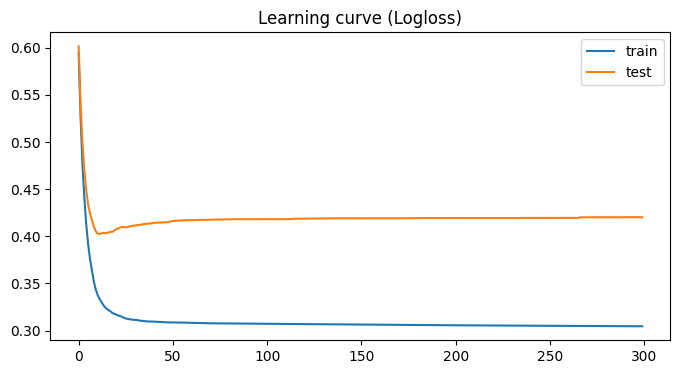

In [158]:
results = model.get_evals_result()

plt.figure(figsize=(8,4))
plt.plot(results['learn']['Logloss'], label='train')
plt.plot(results['validation']['Logloss'], label='test')
plt.legend()
plt.title("Learning curve (Logloss)")
plt.show()

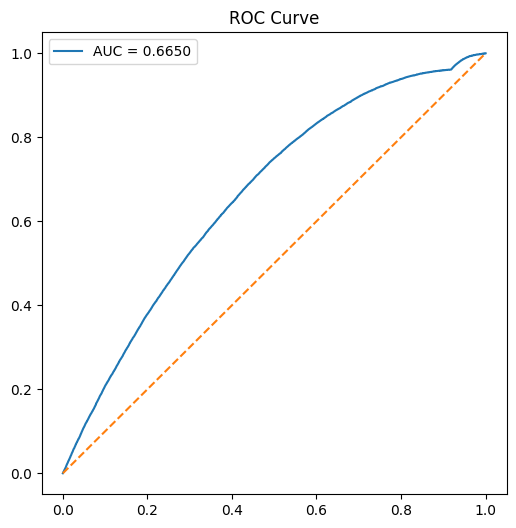

In [159]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

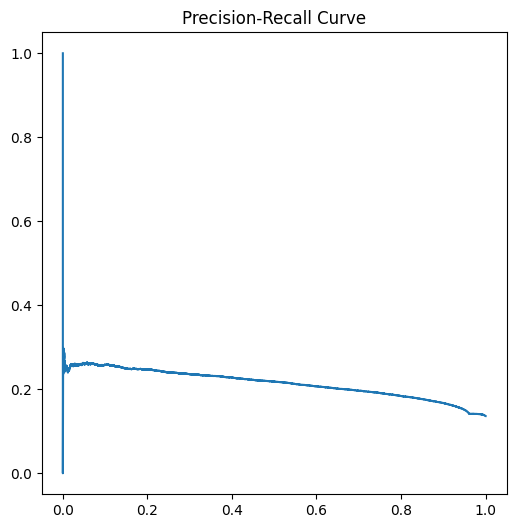

In [160]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, proba)

plt.figure(figsize=(6,6))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.show()

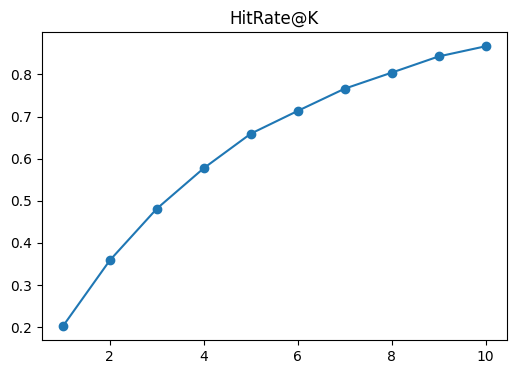

In [161]:
ks = list(range(1, 11))
scores = [hitrate_at_k(test, k) for k in ks]

plt.figure(figsize=(6,4))
plt.plot(ks, scores, marker='o')
plt.title("HitRate@K")
plt.show()

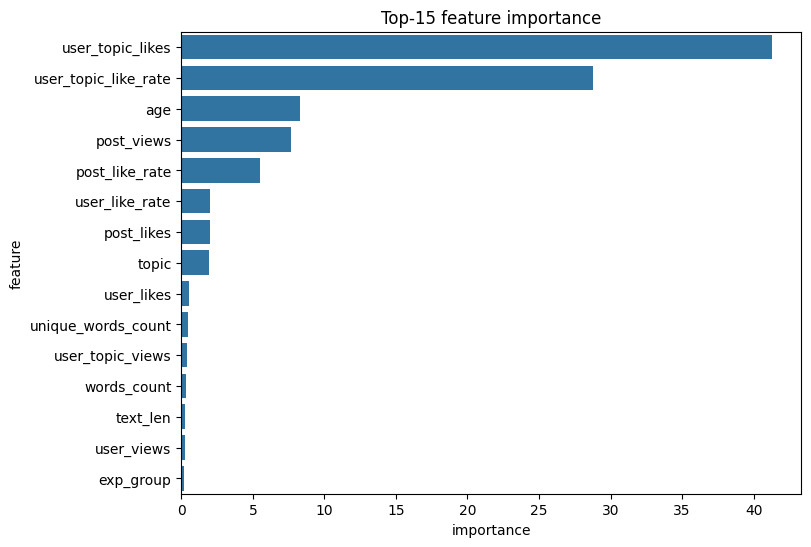

In [162]:
import pandas as pd

feat_imp = pd.DataFrame({
    'feature': model.feature_names_,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature')
plt.title("Top-15 feature importance")
plt.show()